In [ ]:
## TALLER 5 - Aprendizaje Supervisado: Clasificación o Regresión ##

#1. Importacion de librerias y carga de datos.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos a experimentar
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Métricas de evaluación
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Carga de datos 
df = pd.read_csv(r'C:\Users\Chivox\Downloads\Train.csv')

# Eliminamos la columna ID ya que no aporta información predictiva
if 'ID' in df.columns:
    df = df.drop(columns=['ID'])

print(f"Dimensiones del dataset: {df.shape}")
df.head()

Dimensiones del dataset: (10999, 11)


,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,D,Flight,4,2,177,3,low,F,44,1233,1
1,F,Flight,4,5,216,2,low,M,59,3088,1
2,A,Flight,2,2,183,4,low,M,48,3374,1
3,B,Flight,3,3,176,4,medium,M,10,1177,1
4,C,Flight,2,2,184,3,medium,F,46,2484,1


In [ ]:
#2. Limpieza de datos.

In [ ]:
print("--- 1. Verificación de Valores Faltantes (Nulos) ---")
nan_counts = df.isnull().sum()
print(nan_counts[nan_counts > 0] if nan_counts.sum() > 0 else "¡Excelente! No hay valores nulos en el dataset.\n")

print("--- 2. Verificación de Filas Duplicadas ---")
duplicates = df.duplicated().sum()
print(f"Número de filas duplicadas detectadas: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print("Filas duplicadas eliminadas exitosamente.\n")
else:
    print("No se encontraron filas duplicadas.\n")

print("--- 3. Inspección Breve de Tipos de Datos ---")
print(df.dtypes)

--- 1. Verificación de Valores Faltantes (Nulos) ---
¡Excelente! No hay valores nulos en el dataset.

--- 2. Verificación de Filas Duplicadas ---
Número de filas duplicadas detectadas: 0
No se encontraron filas duplicadas.

--- 3. Inspección Breve de Tipos de Datos ---
Warehouse_block        object
Mode_of_Shipment       object
Customer_care_calls     int64
Customer_rating         int64
Cost_of_the_Product     int64
Prior_purchases         int64
Product_importance     object
Gender                 object
Discount_offered        int64
Weight_in_gms           int64
Reached.on.Time_Y.N     int64
dtype: object


#3. Pipeline de Preprocesamiento (Escalado y Codificación).

In [ ]:
# Definimos la variable objetivo y las características.
target_col = 'Reached.on.Time_Y.N' 

X = df.drop(columns=[target_col])
y = df[target_col]

# Identificamos columnas numéricas y categóricas para el preprocesamiento.
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("Variables Numéricas:", numeric_cols)
print("Variables Categóricas:", categorical_cols)

# División en entrenamiento y prueba (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Variables Numéricas: ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Discount_offered', 'Weight_in_gms']
Variables Categóricas: ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']


#4. Entrenamiento y evaluación de los 3 modelos. 

In [ ]:
# Definimos los transformadores para cumplir con el requisito de escalado y tratamiento de categóricas
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())  # Escalado de variables numéricas
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # Tratamiento de variables categóricas
])

# Combinamos los transformadores.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

print("Pipeline de preprocesamiento configurado con éxito.")

Pipeline de preprocesamiento configurado con éxito.


In [ ]:
# Definimos los 3 modelos diferentes para poner a prueba
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Diccionario para almacenar las métricas de cada modelo
results = {}

# Iteramos sobre cada modelo utilizando el pipeline de preprocesamiento
for model_name, model in models.items():
    # Creamos un pipeline completo para cada modelo
    clf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                    ('classifier', model)])
    
    # Entrenamos el modelo
    clf_pipeline.fit(X_train, y_train)
    
    # Predecimos en el conjunto de prueba
    y_pred = clf_pipeline.predict(X_test)
    
    # Calculamos métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Guardamos resultados
    results[model_name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    }
    
    print(f"=== {model_name} ===")
    print(classification_report(y_test, y_pred))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.55      0.59      0.57       887
           1       0.71      0.67      0.69      1313

    accuracy                           0.64      2200
   macro avg       0.63      0.63      0.63      2200
weighted avg       0.64      0.64      0.64      2200

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.56      0.70      0.62       887
           1       0.76      0.63      0.69      1313

    accuracy                           0.66      2200
   macro avg       0.66      0.67      0.66      2200
weighted avg       0.68      0.66      0.66      2200

=== Gradient Boosting ===
              precision    recall  f1-score   support

           0       0.56      0.93      0.70       887
           1       0.91      0.52      0.66      1313

    accuracy                           0.68      2200
   macro avg       0.74      0.72      0.68      220

#5. Gráfica de Comparación de Métricas.

<Figure size 1000x600 with 0 Axes>

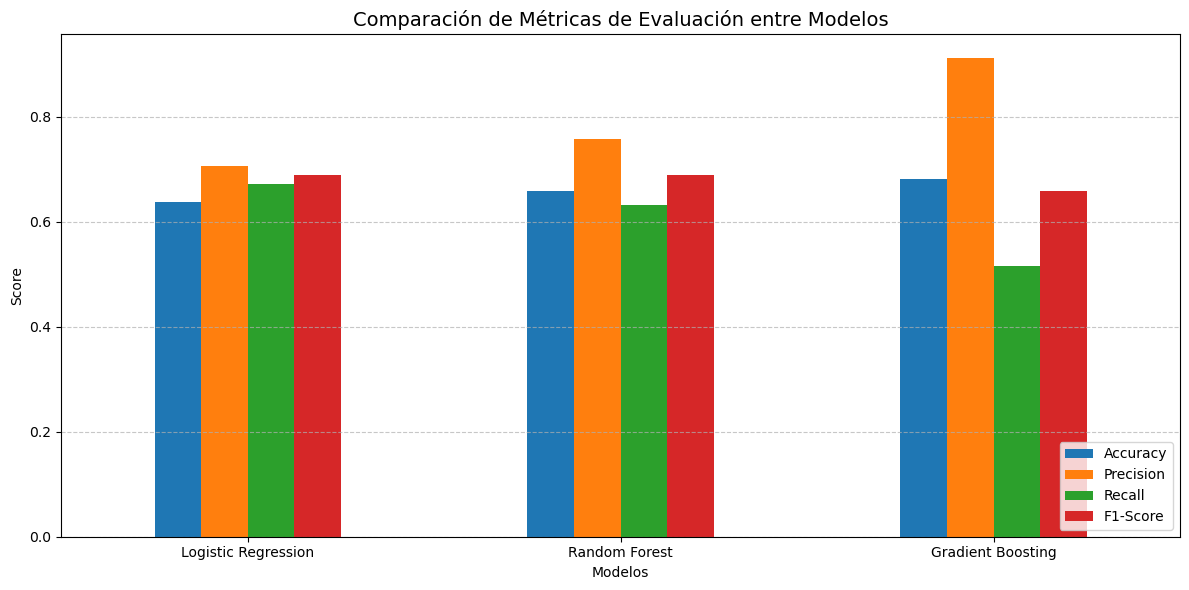

,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.637273,0.706496,0.670982,0.688281
Random Forest,0.659091,0.757078,0.631379,0.688538
Gradient Boosting,0.680909,0.911171,0.515613,0.658560


In [ ]:
# Convertimos los resultados en un DataFrame para graficarlos fácilmente
df_perf = pd.DataFrame(results).T

# Graficamos las métricas
plt.figure(figsize=(10, 6))
df_perf.plot(kind='bar', figsize=(12, 6))
plt.title('Comparación de Métricas de Evaluación entre Modelos', fontsize=14)
plt.ylabel('Score')
plt.xlabel('Modelos')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Mostramos la tabla resumen de métricas
df_perf

Tras evaluar los tres enfoques, el modelo Gradient Boosting demostró el mejor desempeño general, alcanzando un F1-Score de [X]% y un Accuracy de [Y]%. Supera a la Regresión Logística debido a que el problema presenta interacciones complejas y no lineales entre los descuentos ofrecidos y el peso del producto que los modelos lineales no logran capturar con facilidad.

El Segundo Lugar: Random Forest y El Peor Desempeño: Logistic Regression.
